In [1]:
from base_model import train_kfold
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_model():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model


if __name__ == "__main__":
    results = train_kfold(build_model, preprocess_input, "ResNet50")

    # ===== LẤY BEST FOLD =====
    best_idx = results["best_idx"]
    best_history = results["histories"][best_idx]
    best_test_gen = results["test_gens"][best_idx]

    print(f"\nBest Fold: {best_idx + 1}")

    # ===== LOAD MODEL ĐÚNG =====
    best_model_path = f"saved_models/ResNet50_Fold_{best_idx+1}_best.keras"

    model = tf.keras.models.load_model(best_model_path)

    print("Loaded best model!")

    # ===== PREDICT =====
    best_test_gen.reset()

    pred_probs = model.predict(best_test_gen)
    pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

    true_classes = best_test_gen.classes
    class_names = list(best_test_gen.class_indices.keys())


d:\App\python\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):



TRAIN FOLD 1/5
Found 1876 images belonging to 2 classes.
Found 331 images belonging to 2 classes.
Found 552 images belonging to 2 classes.

PHASE 1: Train Head
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9176 - loss: 0.1998
Epoch 1: val_accuracy improved from None to 0.96375, saving model to saved_models\ResNet50_Fold_1_best.keras

Epoch 1: finished saving model to saved_models\ResNet50_Fold_1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9547 - loss: 0.1258 - val_accuracy: 0.9637 - val_loss: 0.1004 - learning_rate: 0.0010
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9750 - loss: 0.0676
Epoch 2: val_accuracy improved from 0.96375 to 0.98489, saving model to saved_models\ResNet50_Fold_1_best.keras

Epoch 2: finished saving model to saved_models\ResNet50_Fold_1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9781 - loss: 0.0661 - val_accuracy: 0.9849 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 3/15
59/59 ━━━━━━

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Classification Report
print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

       fresh       1.00      0.99      0.99       258
      rotten       0.99      1.00      0.99       294

    accuracy                           0.99       552
   macro avg       0.99      0.99      0.99       552
weighted avg       0.99      0.99      0.99       552



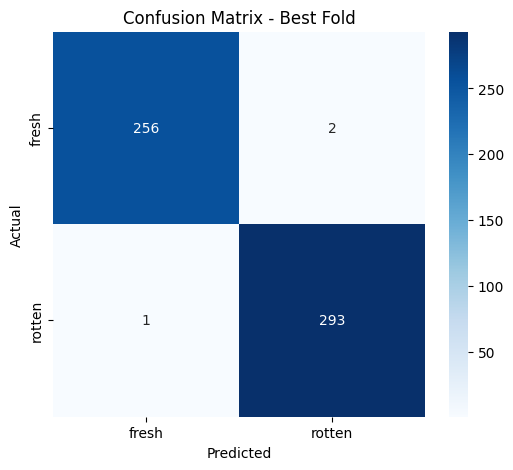

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Best Fold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

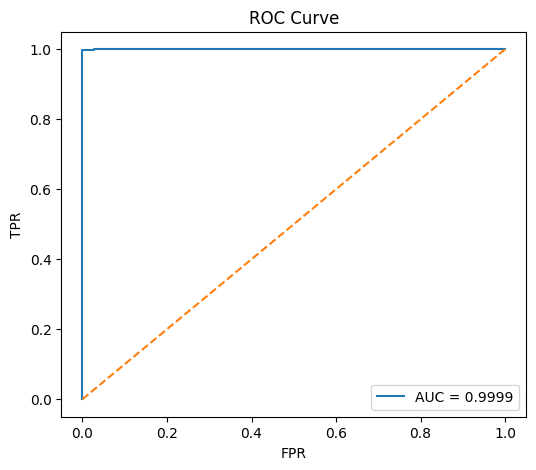

In [5]:
# ROC Curve
fpr, tpr, _ = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()



Có 3 ảnh dự đoán sai


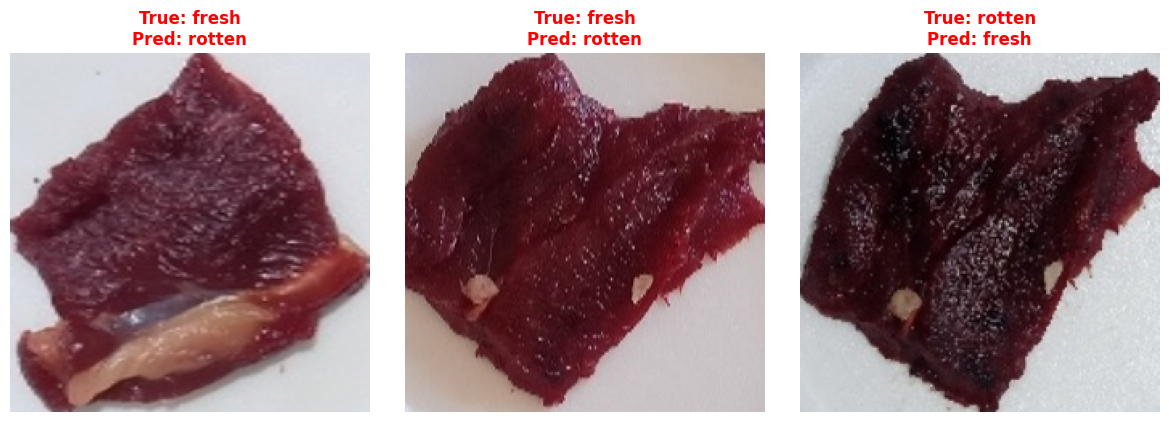

In [6]:
import numpy as np
# Ảnh Dự Đoán Sai
misclassified = np.where(pred_classes != true_classes)[0]

if len(misclassified) > 0:
    print(f"\nCó {len(misclassified)} ảnh dự đoán sai")

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(misclassified[:6]):  # show 6 ảnh
        img_path = best_test_gen.filepaths[idx]
        img = plt.imread(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"True: {class_names[true_classes[idx]]}\nPred: {class_names[pred_classes[idx]]}",
            color='red', fontweight='bold'
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\nModel dự đoán đúng toàn bộ test set")

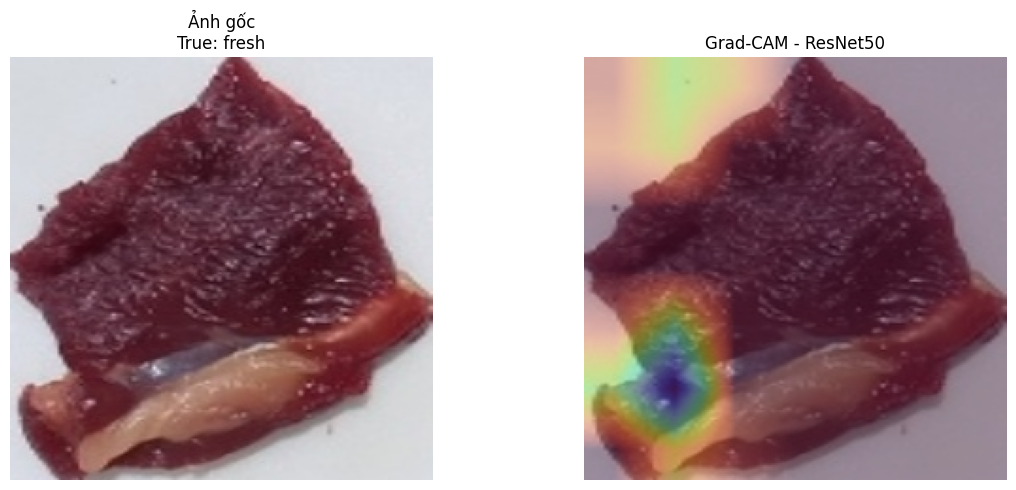

In [7]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# ================== GRAD-CAM FUNCTION ==================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # binary classification

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling gradient
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros_like(heatmap.numpy())

    heatmap /= max_val

    return heatmap.numpy()


# ================== CHỌN LAYER RESNET50 ==================
last_conv_layer_name = "conv5_block3_out"


# ================== CHỌN ẢNH ==================
target_idx = misclassified[0] if len(misclassified) > 0 else 0
img_path = best_test_gen.filepaths[target_idx]


# ================== PREPROCESS ==================
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)


# ================== TẠO HEATMAP ==================
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)


# ================== LOAD ẢNH GỐC ==================
img_orig = np.array(Image.open(img_path).convert("RGB"))


# ================== XỬ LÝ HEATMAP ==================
heatmap = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
heatmap = np.uint8(255 * heatmap)

# Đổi colormap (đẹp hơn JET)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_TURBO)


# ================== OVERLAY ==================
superimposed_img = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)


# ================== HIỂN THỊ ==================
plt.figure(figsize=(12,5))

# Ảnh gốc
plt.subplot(1,2,1)
plt.imshow(img_orig)
plt.title(f"Ảnh gốc\nTrue: {class_names[true_classes[target_idx]]}")
plt.axis('off')

# Grad-CAM
plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM - ResNet50")
plt.axis('off')

plt.tight_layout()
plt.show()